<a href="https://colab.research.google.com/github/hosseinta2/RL/blob/main/Q_learning_atari.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [29]:
import typing as tt
import gymnasium as gym
from collections import defaultdict

env_name = "FrozenLake-v1"
Gamma = 0.9
Alpha = 0.2
Test_episodes = 20
state = int
action = int
Q_valKey = tt.Tuple[state,action] # dictionary for storing Q_{s,a}
class Agent:
  def __init__(self):
    self.env = gym.make(env_name)
    self.state,_ = self.env.reset()
    self.trigger = False
    self.values: tt.DefaultDict[Q_valKey,float] = defaultdict(float)
  def sample_env(self): # sample an action for the current state and return reward,next_state,current_state and the action
    old_state = self.state
    action = self.env.action_space.sample()
    next_state, reward, is_done, is_truncacted,_ = self.env.step(action)
    if is_done or is_truncacted:
      self.state,_ = self.env.reset()
      self.trigger = True # if it's truncated, don't include max_a' Q_{s',a'} in updating Q
    else:
      self.trigger = False
      self.state = next_state
    return old_state, next_state, action, reward
  def best_value_action(self,state): # returns max_a' Q_{s',a'} and arg_max_a' Q_{s',a'}
    best_val = -float("inf")
    for action in range(self.env.action_space.n):
      Q_s_a = self.values[(state,action)]
      if Q_s_a>best_val:
        best_val = Q_s_a
        best_action = action
    return best_val,best_action

  def update_val(self,state,action,reward,next_state): # update the Q_{s,a} table
    best_val,_ = self.best_value_action(next_state)
    if self.trigger:#if it's truncated, don't include max_a' Q_{s',a'} in updating Q
      self.values[(state,action)] = self.values[(state,action)] *(1-Alpha) + Alpha*reward
    else:
      self.values[(state,action)] = self.values[(state,action)] *(1-Alpha) + Alpha*(reward+Gamma*best_val)

  def play_episode(self,env:gym.Env): # testing the Q_{s,a} table
    total_reward = 0
    state,_ = env.reset()
    while True:
        _,action = self.best_value_action(state)
        next_state,reward,is_done,is_truncated,_=env.step(action)
        total_reward +=reward
        if is_done or is_truncated:
          break
        state = next_state
    return total_reward


In [30]:
agent = Agent()
test_env = gym.make(env_name)
iter_num = 0
num_test_episodes = 10
reward_vec = []
max_reward = 0
while iter_num<10000:
  iter_num +=1
  old_state,next_state,action, reward = agent.sample_env()
  agent.update_val(old_state,action,reward,next_state)
  test_reward = 0
  for i in range(num_test_episodes): # test the model
    test_reward += agent.play_episode(test_env)
  test_reward /= num_test_episodes
  reward_vec.append(test_reward)
  max_reward = max(test_reward,max_reward)
  if iter_num%1000==0:
    print(max_reward)
  if max_reward>=0.8:
    break


0.0
0.4
0.5
0.5
0.6
0.7
0.8
0.8
0.8
0.8


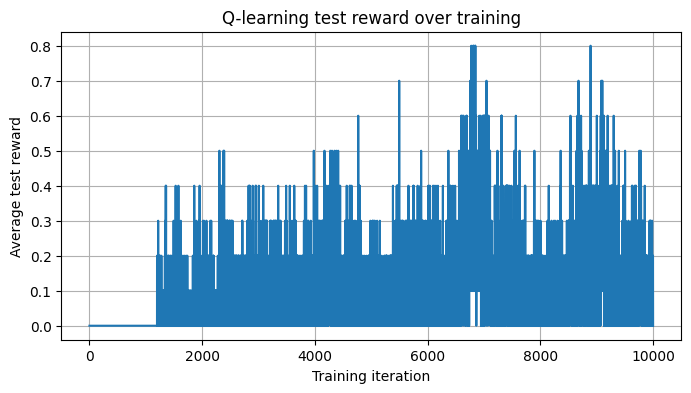

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(reward_vec)
plt.xlabel("Training iteration")
plt.ylabel("Average test reward")
plt.title("Q-learning test reward over training")
plt.grid(True)
plt.show()